# Дообучение vehicle OSNet

Этот ноутбук продолжает обучение публичной `vehicle-reid-0001 / OSNet-AIN x1.0` на официальном `train.csv`. Он не использует test query/gallery при обучении или выборе гиперпараметров.

Порядок: окружение → разбиение → проверка кропов → защитные аугментации → загрузка ONNX в PyTorch → smoke test → обучение → аудит зоны номера и отказа → финальная модель.

## 1. Запуск и параметры

Перед открытием ноутбука из корня репозитория выполните:

```bash
uv pip install --python .venv/bin/python -r requirements-train.txt
uv pip check --python .venv/bin/python
.venv/bin/python -m jupyter lab
```

Не используйте `pip install` без явного Python: так зависимости могут попасть в системное окружение и конфликтовать с другими проектами.

In [1]:
import os
import sys
from pathlib import Path

# Работает и при запуске kernel из notebooks/, и из корня проекта.
if not Path('backend').exists() and (Path.cwd().parent / 'backend').exists():
    os.chdir(Path.cwd().parent)
assert Path('backend').exists(), 'Запустите Jupyter из корня Car-classification-MSK'

import json
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

from backend.core import DATASET, STOCK_MODEL, bbox, crop_image
from backend.evaluate import threshold_curve
from training.pipeline import (TrainConfig, ensure_splits, evaluate_split, fit, fit_final,
    initialize_model, lower_center_invariance, mask_lower_center, occlusion_sensitivity,
    parity_check, prepare_training, rank_split, save_final, select_device, set_seed,
    split_summary, training_losses, VehicleDataset)

CONFIG = TrainConfig(
    epochs=20,
    identities_per_batch=8,  # P
    images_per_identity=4,   # K; batch = P × K = 32
    learning_rate=3e-4,
    weight_decay=5e-4,
    triplet_margin=0.3,
    triplet_weight=1.0,
    consistency_weight=0.2,
    label_smoothing=0.1,
    num_workers=0,           # Поднимите до 2–4 на Linux, если чтение тормозит
    mode='development',
    use_augmentation=True,
)
RUN_DEVELOPMENT_TRAINING = True  # Сначала выполните smoke test, затем поменяйте на True
DEVICE = select_device()
set_seed(CONFIG.seed)
print('python:', sys.executable)
print('device:', DEVICE, '| torch:', torch.__version__, '| batch:', CONFIG.batch_size)

python: /Users/elvsevolod/Desktop/учеба/Учёба 4 курс/Хакатон мск сентябрь/Car-classification-MSK/.venv/bin/python
device: mps | torch: 2.14.0 | batch: 32


## 2. Разбиение без утечки

`development` использует 925 identity для обучения, 307 для калибровки порога и 309 для независимой validation. Один `vehicle_id` и точные копии одного полного кадра не пересекают разделы. Если `artifacts/splits.json` отсутствует или не соответствует CSV, он создаётся заново.

In [2]:
rows, split = ensure_splits(DATASET)
summary = split_summary(rows, split)
print(json.dumps(summary, ensure_ascii=False, indent=2))
assert summary == {
    'train': {'identities': 925, 'images': 5717},
    'calibration': {'identities': 307, 'images': 1903},
    'validation': {'identities': 309, 'images': 1936},
}

{
  "train": {
    "identities": 925,
    "images": 5717
  },
  "calibration": {
    "identities": 307,
    "images": 1903
  },
  "validation": {
    "identities": 309,
    "images": 1936
  }
}


## 3. Посмотреть реальные кропы

Resize до 208×208 выполняется уже после строгого BBox-кропа. В первой версии сохраняем официальный preprocessing; padding можно сравнить отдельным контролируемым экспериментом.

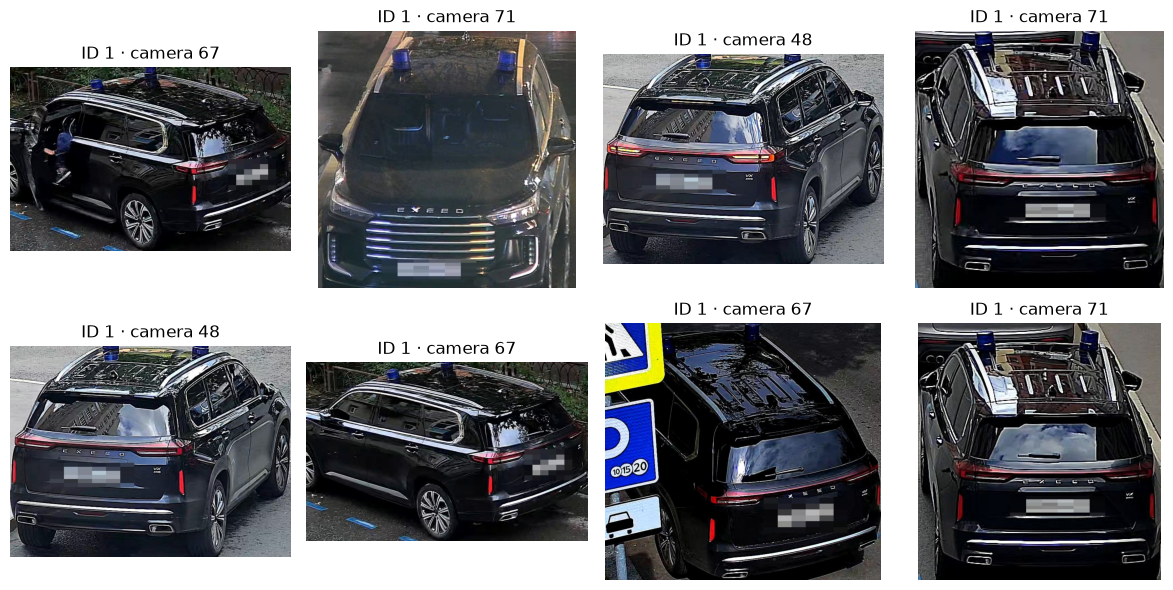

In [3]:
examples = [row for row in rows if row['vehicle_id'] in set(split['identities']['train'][:4])][:8]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for axis, row in zip(axes.flat, examples):
    with Image.open(DATASET / 'images' / f"{row['image_id']}.jpg") as image:
        axis.imshow(crop_image(image, bbox(row)))
    axis.set_title(f"ID {row['vehicle_id']} · camera {row['camera_id']}")
    axis.axis('off')
plt.tight_layout()

## 4. Даталоадер и PK-batch

Каждый батч содержит `P=8` автомобилей и `K=4` изображения каждого. Поэтому Batch Hard Triplet Loss всегда видит положительные и отрицательные пары. `camera_id` не подаётся модели.

In [4]:
train_rows, label_map, sampler, train_loader = prepare_training(rows, split, CONFIG, DATASET)
clean_images, robust_images, labels, image_ids = next(iter(train_loader))
print('train images:', len(train_rows), '| train identities:', len(label_map))
print('batch:', tuple(clean_images.shape), '| unique labels:', labels.unique().numel())
assert clean_images.shape == robust_images.shape == (CONFIG.batch_size, 3, 208, 208)
assert labels.unique().numel() == CONFIG.identities_per_batch
assert all((labels == label).sum() == CONFIG.images_per_identity for label in labels.unique())

train images: 5717 | train identities: 925
batch: (32, 3, 208, 208) | unique labels: 8


## 5. Защитные аугментации

Датасет возвращает два вида одного BBox-кропа. `clean` содержит обычные flip/ColorJitter. `robust` дополнительно получает blur, снижение разрешения, JPEG-артефакты, Random Erasing и перекрытие нижней центральной области. Это не детектор номера, а общая защита от shortcut-признаков.

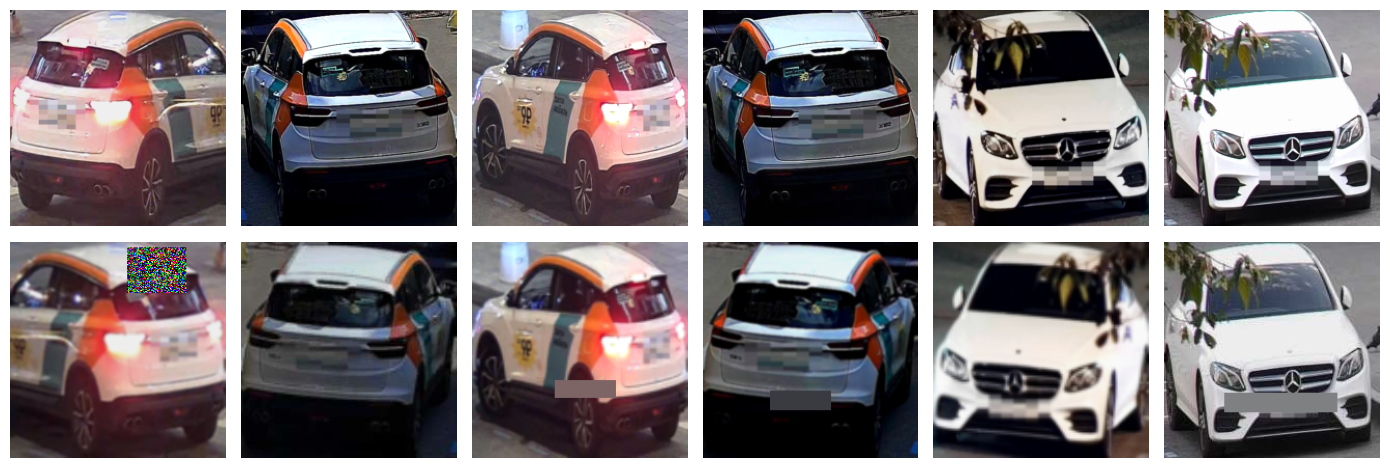

In [5]:
MEAN = torch.tensor([.485, .456, .406]).view(3, 1, 1)
STD = torch.tensor([.229, .224, .225]).view(3, 1, 1)
def display_tensor(tensor):
    return (tensor.cpu() * STD + MEAN).clamp(0, 1).permute(1, 2, 0)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for index in range(6):
    axes[0, index].imshow(display_tensor(clean_images[index])); axes[0, index].axis('off')
    axes[1, index].imshow(display_tensor(robust_images[index])); axes[1, index].axis('off')
axes[0, 0].set_ylabel('clean'); axes[1, 0].set_ylabel('robust')
plt.tight_layout()

## 6. Перенос стоковых весов ONNX в обучаемый PyTorch

Классификационная голова создаётся заново для наших train identity. Энкодер загружается из того же ONNX, который использовал baseline. Проверка parity должна дать cosine почти 1.0. Если она не проходит, обучение запускать нельзя.

In [6]:
model, loaded_tensors = initialize_model(len(label_map), DEVICE, STOCK_MODEL)
parity = parity_check(model, train_rows[0], DEVICE, DATASET, STOCK_MODEL)
print('loaded ONNX tensors:', loaded_tensors)
print(parity)
assert parity['cosine_similarity'] > 0.99999
assert parity['max_absolute_difference'] < 1e-3

loaded ONNX tensors: 559
{'max_absolute_difference': 2.086162567138672e-07, 'cosine_similarity': 1.0}


## 7. Smoke test одной оптимизационной итерации

Проверяет forward, Cross Entropy, Batch Hard Triplet, consistency loss и backward. Consistency loss сближает эмбеддинг robust-view с stop-gradient эмбеддингом clean-view. После smoke-шага модель заново инициализируется из стоковых весов.

In [7]:
smoke_optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG.learning_rate)
smoke_optimizer.zero_grad(set_to_none=True)
smoke_clean, smoke_robust, smoke_labels = clean_images.to(DEVICE), robust_images.to(DEVICE), labels.to(DEVICE)
smoke_losses = training_losses(model, smoke_clean, smoke_robust, smoke_labels, CONFIG)
smoke_losses['loss'].backward()
smoke_optimizer.step()
assert all(torch.isfinite(value) for value in smoke_losses.values())
print({name: round(float(value.detach()), 6) for name, value in smoke_losses.items()})
del model, smoke_clean, smoke_robust, smoke_labels, smoke_losses, smoke_optimizer
if DEVICE.type == 'cuda': torch.cuda.empty_cache()
model, _ = initialize_model(len(label_map), DEVICE, STOCK_MODEL)

{'loss': 7.088091, 'cross_entropy': 6.825982, 'triplet': 0.212247, 'consistency': 0.249313, 'accuracy': 0.0}


## 8. Development-обучение

Loss = Cross Entropy + Batch Hard Triplet + 0.2 × consistency loss. После каждой эпохи порог выбирается только на calibration, затем с тем же порогом считываются validation mAP, Rank-1/5, mINP, candidate F1 и TNR. `best.pt` выбирается по validation mAP.

После каждой эпохи выводятся число оставшихся эпох, время train, evaluation и всей эпохи, общее прошедшее время, ETA до завершения и лучший mAP. Эти же секунды сохраняются в `history.json`.

Для быстрой проверки сначала поставьте `CONFIG.epochs = 1`. Для сравнимого эксперимента верните 20 и запустите kernel заново.

In [8]:
history = fit(model, rows, split, train_loader, sampler, DEVICE, CONFIG) if RUN_DEVELOPMENT_TRAINING else []
if not history:
    print('Полное обучение выключено. Установите RUN_DEVELOPMENT_TRAINING = True и повторите запуск с начала.')

epoch 1:   0%|          | 0/115 [00:00<?, ?it/s]

embedding:   0%|          | 0/19 [00:00<?, ?it/s]

embedding:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 1/20 | осталось эпох: 19 | эпоха: 00:02:05 | train: 00:01:28 | evaluation: 00:00:37 | прошло: 00:02:05 | ETA: 00:39:38 | best mAP: 0.6278
{
  "epoch": 1,
  "lr": 0.0003,
  "train": {
    "loss": 7.088997268676758,
    "cross_entropy": 6.83760692762292,
    "triplet": 0.19889278834604698,
    "consistency": 0.2624879288932552,
    "accuracy": 0.0
  },
  "threshold": 0.7081643342971802,
  "calibration": {
    "mAP": 0.5914504662198006,
    "Rank_1": 0.6138211382113821,
    "Rank_5": 0.7560975609756098,
    "mINP": 0.49280887545172786,
    "candidate_precision": 0.3845419847328244,
    "candidate_recall": 0.45027932960893857,
    "candidate_F1": 0.4148224395265054,
    "TNR": 0.4262295081967213,
    "known_queries": 246,
    "unknown_queries": 61,
    "TP": 403,
    "FP": 645,
    "FN": 492,
    "true_refusals": 26
  },
  "validation": {
    "mAP": 0.6278018056756891,
    "Rank_1": 0.6275303643724697,
    "Rank_5": 0.7975708502024291,
    "mINP": 0.5467045419902943,
    "candidate_p

epoch 2:   0%|          | 0/115 [00:00<?, ?it/s]

...

Epoch 19/20 | осталось эпох: 1 | эпоха: 00:02:05 | train: 00:01:28 | evaluation: 00:00:36 | прошло: 00:39:35 | ETA: 00:02:05 | best mAP: 0.7740
{
  "epoch": 19,
  "lr": 7.341522555726972e-06,
  "train": {
    "loss": 2.5462461305701214,
    "cross_entropy": 2.5210490745046865,
    "triplet": 0.002578592429990354,
    "consistency": 0.11309228021165599,
    "accuracy": 0.9752717391304347
  },
  "threshold": 0.6241011023521423,
  "calibration": {
    "mAP": 0.7484820670525845,
    "Rank_1": 0.7520325203252033,
    "Rank_5": 0.8699186991869918,
    "mINP": 0.6773411215308921,
    "candidate_precision": 0.5277777777777778,
    "candidate_recall": 0.6581005586592179,
    "candidate_F1": 0.5857782197911486,
    "TNR": 0.5409836065573771,
    "known_queries": 246,
    "unknown_queries": 61,
    "TP": 589,
    "FP": 527,
    "FN": 306,
    "true_refusals": 33
  },
  "validation": {
    "mAP": 0.7690555991004853,
    "Rank_1": 0.7611336032388664,
    "Rank_5": 0.8825910931174089,
    "mINP": 0.

epoch 20:   0%|          | 0/115 [00:00<?, ?it/s]

embedding:   0%|          | 0/19 [00:00<?, ?it/s]

embedding:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 20/20 | осталось эпох: 0 | эпоха: 00:02:05 | train: 00:01:28 | evaluation: 00:00:37 | прошло: 00:41:39 | ETA: 00:00:00 | best mAP: 0.7740
{
  "epoch": 20,
  "lr": 1.8467489107293517e-06,
  "train": {
    "loss": 2.5201399844625723,
    "cross_entropy": 2.4959959465524424,
    "triplet": 0.0018352880426075148,
    "consistency": 0.11154372588447903,
    "accuracy": 0.9763586956521739
  },
  "threshold": 0.6491256356239319,
  "calibration": {
    "mAP": 0.7515552166837479,
    "Rank_1": 0.7520325203252033,
    "Rank_5": 0.8821138211382114,
    "mINP": 0.6803988097305588,
    "candidate_precision": 0.5708200212992546,
    "candidate_recall": 0.5988826815642458,
    "candidate_F1": 0.5845147219193021,
    "TNR": 0.6229508196721312,
    "known_queries": 246,
    "unknown_queries": 61,
    "TP": 536,
    "FP": 403,
    "FN": 359,
    "true_refusals": 38
  },
  "validation": {
    "mAP": 0.7694450673606955,
    "Rank_1": 0.7651821862348178,
    "Rank_5": 0.8947368421052632,
    "mINP": 

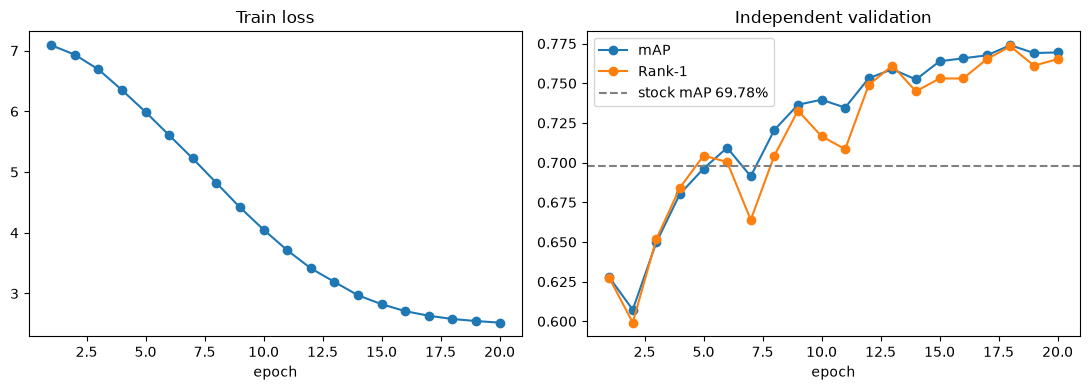

In [9]:
if history:
    epochs = [item['epoch'] for item in history]
    maps = [item['validation']['mAP'] for item in history]
    rank1 = [item['validation']['Rank_1'] for item in history]
    losses = [item['train']['loss'] for item in history]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(epochs, losses, marker='o'); axes[0].set_title('Train loss'); axes[0].set_xlabel('epoch')
    axes[1].plot(epochs, maps, marker='o', label='mAP'); axes[1].plot(epochs, rank1, marker='o', label='Rank-1')
    axes[1].axhline(.697811803, color='gray', linestyle='--', label='stock mAP 69.78%')
    axes[1].set_title('Independent validation'); axes[1].set_xlabel('epoch'); axes[1].legend()
    plt.tight_layout()

In [10]:
best_path = Path('artifacts/training/best.pt')
best = torch.load(best_path, map_location=DEVICE, weights_only=True) if best_path.exists() else None
if best is not None:
    model.load_state_dict(best['model'])
    print('best epoch:', best['epoch'])
    print('threshold:', best['threshold'])
    print('validation:', json.dumps(best['validation'], indent=2))

best epoch: 18
threshold: 0.6030340194702148
validation: {
  "mAP": 0.7739921679882028,
  "Rank_1": 0.7732793522267206,
  "Rank_5": 0.8866396761133604,
  "mINP": 0.7052174557845554,
  "candidate_precision": 0.5034377387318564,
  "candidate_recall": 0.7354910714285714,
  "candidate_F1": 0.5977324263038549,
  "TNR": 0.46774193548387094,
  "known_queries": 247,
  "unknown_queries": 62,
  "TP": 659,
  "FP": 650,
  "FN": 237,
  "true_refusals": 29
}


## 9. Аудит зоны номера и качества изображения

Аудит не ищет и не распознаёт номер. Он закрывает фиксированную нижнюю центральную область как proxy и измеряет изменение эмбеддинга. Карта окклюзий показывает, какие части кропа сильнее влияют на cross-camera similarity. Это инженерный аудит, а не гарантия точной локализации номера.

{
  "samples": 64,
  "mean_cosine": 0.975523054599762,
  "p05_cosine": 0.9516075849533081,
  "min_cosine": 0.9293918609619141,
  "fraction_below_0_95": 0.046875
}


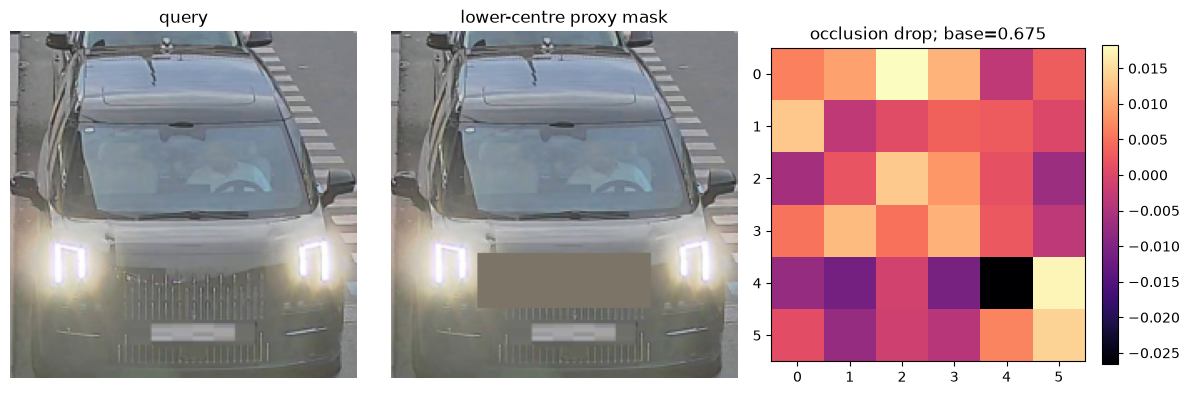

In [11]:
validation_rows = [row for row in rows if row['vehicle_id'] in set(split['identities']['validation'])]
invariance = lower_center_invariance(model, validation_rows, DEVICE, DATASET, max_samples=64)
print(json.dumps(invariance, indent=2))

pair = None
for identity in split['identities']['validation']:
    items = [row for row in validation_rows if row['vehicle_id'] == identity]
    for query in items:
        reference = next((row for row in items if row['camera_id'] != query['camera_id']), None)
        if reference is not None:
            pair = query, reference
            break
    if pair is not None:
        break
assert pair is not None
audit_dataset = VehicleDataset([{**row, 'label': 0} for row in pair], DATASET, augment=False)
query_tensor, _, _ = audit_dataset[0]
reference_tensor, _, _ = audit_dataset[1]
base_similarity, heatmap = occlusion_sensitivity(model, query_tensor, reference_tensor, DEVICE)
masked_tensor = mask_lower_center(query_tensor)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(display_tensor(query_tensor)); axes[0].set_title('query')
axes[1].imshow(display_tensor(masked_tensor)); axes[1].set_title('lower-centre proxy mask')
image = axes[2].imshow(heatmap, cmap='magma'); axes[2].set_title(f'occlusion drop; base={base_similarity:.3f}')
for axis in axes[:2]: axis.axis('off')
fig.colorbar(image, ax=axes[2], fraction=.046); plt.tight_layout()

## 10. Кривая порога отказа

Полный расчёт выключен в smoke-режиме, так как требует инференса всей calibration. Порог подбирается только на calibration по candidate F1; validation и test для подбора не используются. TNR показывает долю правильных пустых ответов.

In [12]:
RUN_REFUSAL_AUDIT = False
if RUN_REFUSAL_AUDIT:
    calibration_ranked = rank_split(model, rows, split['identities']['calibration'], DEVICE, DATASET, CONFIG.seed, CONFIG.num_workers)
    curve = threshold_curve(calibration_ranked)
    selected_threshold = max(curve, key=lambda item: (item['candidate_F1'], item['threshold']))
    visible = [item for item in curve if item['threshold'] <= 1]
    fig, axis = plt.subplots(figsize=(9, 4))
    axis.plot([item['threshold'] for item in visible], [item['candidate_F1'] for item in visible], label='candidate F1')
    axis.plot([item['threshold'] for item in visible], [item['TNR'] for item in visible], label='TNR')
    axis.axvline(selected_threshold['threshold'], color='black', linestyle='--', label='selected threshold')
    axis.set(xlabel='cosine threshold', ylabel='metric', title='Refusal calibration only')
    axis.legend(); axis.grid(alpha=.25); plt.show()
    print(json.dumps(selected_threshold, indent=2))
else:
    print('Аудит отказа выключен. После обучения установите RUN_REFUSAL_AUDIT = True.')

Аудит отказа выключен. После обучения установите RUN_REFUSAL_AUDIT = True.


## 11. Финальное обучение на 1234 identity — запускать после выбора настроек

Эта секция по умолчанию выключена. Она заново инициализирует OSNet из стоковых весов, объединяет первоначальные train+validation и обучает ровно столько эпох, сколько оказалось лучшим в development. 307 calibration identity остаются невидимыми и используются только для порога. После объединения отдельной validation-оценки у финальной модели уже нет; честный результат эксперимента остаётся в `best.pt/history.json`.

In [13]:
RUN_FINAL = False  # Поменяйте на True только после выбора конфигурации

if RUN_FINAL:
    assert best is not None, 'Сначала завершите development-обучение и получите best.pt'
    final_config = TrainConfig(**{**CONFIG.__dict__, 'mode': 'final'})
    final_rows, final_labels, final_sampler, final_loader = prepare_training(rows, split, final_config, DATASET)
    final_model, _ = initialize_model(len(final_labels), DEVICE, STOCK_MODEL)
    fit_final(final_model, final_loader, final_sampler, DEVICE, final_config, epochs=best['epoch'])
    final_checkpoint, final_onnx = save_final(final_model, rows, split, DEVICE, final_config)
    print('final train identities:', len(final_labels), '| images:', len(final_rows))
    print('ONNX:', final_onnx, '| calibration threshold:', final_checkpoint['threshold'])

## Результаты

Development сохраняет `artifacts/training/best.pt` и `history.json`. Финальный режим дополнительно создаёт `artifacts/training/final/final.pt`, `osnet_finetuned.onnx`, JSON с preprocessing и порогом. Папка `artifacts/` исключена из Git; для каждого важного эксперимента сохраните checkpoint и историю отдельно.

Следующий инженерный шаг после финального ONNX: проверить parity экспорта, пересчитать gallery и подключить новый путь модели к API.